In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt

In [7]:
data = {
    'Weather': ['Sunny', 'Cloudy', 'Sunny', 'Cloudy', 'Rainy',
                'Rainy', 'Rainy', 'Sunny', 'Cloudy', 'Rainy'],

    'Temperature': ['Hot', 'Hot', 'Mild', 'Mild', 'Mild',
                    'Cool', 'Mild', 'Hot', 'Hot', 'Mild'],

    'Humidity': ['High', 'High', 'Normal', 'High', 'High',
                 'Normal', 'High', 'High', 'Normal', 'High'],

    'Wind': ['Weak', 'Weak', 'Strong', 'Strong', 'Strong',
             'Strong', 'Weak', 'Strong', 'Weak', 'Strong'],

    'Play': ['No', 'Yes', 'Yes', 'Yes', 'No',
             'No', 'Yes', 'No', 'Yes', 'No']
}
df = pd.DataFrame(data)
df

,Weather,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Cloudy,Hot,High,Weak,Yes
2,Sunny,Mild,Normal,Strong,Yes
3,Cloudy,Mild,High,Strong,Yes
4,Rainy,Mild,High,Strong,No
5,Rainy,Cool,Normal,Strong,No
6,Rainy,Mild,High,Weak,Yes
7,Sunny,Hot,High,Strong,No
8,Cloudy,Hot,Normal,Weak,Yes
9,Rainy,Mild,High,Strong,No


In [18]:
encoder = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoder[col] = le
df


,Weather,Temperature,Humidity,Wind,Play
0,2,1,0,1,0
1,0,1,0,1,1
2,2,2,1,0,1
3,0,2,0,0,1
4,1,2,0,0,0
5,1,0,1,0,0
6,1,2,0,1,1
7,2,1,0,0,0
8,0,1,1,1,1
9,1,2,0,0,0


In [21]:
x = df.drop('Play', axis=1)

y = df['Play']

In [22]:
print("Features")
print(x)

Features
   Weather  Temperature  Humidity  Wind
0        2            1         0     1
1        0            1         0     1
2        2            2         1     0
3        0            2         0     0
4        1            2         0     0
5        1            0         1     0
6        1            2         0     1
7        2            1         0     0
8        0            1         1     1
9        1            2         0     0


In [25]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state = 42
)

In [26]:
model.fit(x,y)
print("Model Trained Succesfully")

Model Trained Succesfully


In [27]:
importance = model.feature_importances_

for feature, score in zip(x.columns, importance):
    print(feature, ":", score)

Weather : 0.39581560200335825
Temperature : 0.20418439799664173
Humidity : 0.2754887502163469
Wind : 0.12451124978365313


In [28]:
new_data = pd.DataFrame({
    'Weather': ['Sunny'],
    'Temperature': ['Mild'],
    'Humidity': ['Normal'],
    'Wind': ['Strong']
})

In [29]:
for col in new_data.columns:
    new_data[col] = encoder[col].transform(new_data[col])

prediction = model.predict(new_data)

result = encoder['Play'].inverse_transform(prediction)

print("Prediction =", result[0])

Prediction = Yes


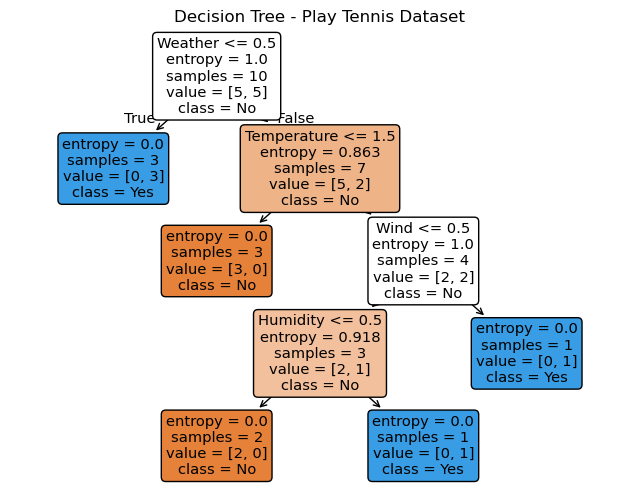

In [31]:
plt.figure(figsize=(8, 6))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - Play Tennis Dataset")
plt.show()

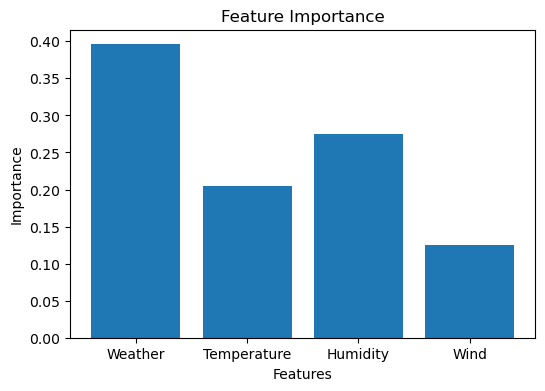

In [33]:
plt.figure(figsize=(6, 4))

plt.bar(
    x.columns,
    model.feature_importances_
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [35]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x)

accuracy = accuracy_score(y, y_pred)

print("Accuracy =", accuracy * 100, "%")

Accuracy = 100.0 %
